# T1 - Jogo da Velha com Machine Learning
**PUCRS - Inteligência Artificial | Grupo **

Classificador de estados do tabuleiro 3×3 em 4 classes:
- `tem_jogo` — partida em andamento
- `x_venceu` — jogador X ganhou
- `o_venceu` — jogador O ganhou
- `empate` — tabuleiro completo sem vencedor

---
## Seção 0 - Configuração e Constantes

In [4]:
# 0.1 - Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
from copy import deepcopy
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


---
## Seção 1 - Carregamento e Análise Exploratória

In [9]:
# 1.1 - Carregamento do dataset UCI

DATASET_PATH = './tic+tac+toe+endgame/tic-tac-toe.data'

df_raw = pd.read_csv(DATASET_PATH, header=None, names=COLS)
print(f'Dataset carregado: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas')
df_raw.head()

Dataset carregado: 958 linhas x 10 colunas


,c1,c2,c3,c4,c5,c6,c7,c8,c9,label
0,x,x,x,x,o,o,x,o,o,positive
1,x,x,x,x,o,o,o,x,o,positive
2,x,x,x,x,o,o,o,o,x,positive
3,x,x,x,x,o,o,o,b,b,positive
4,x,x,x,x,o,o,b,o,b,positive


In [10]:
# 0.2 - Constantes globais
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

CLASS_NAMES = ['tem_jogo', 'x_venceu', 'o_venceu', 'empate']

CELL_COLS = ['c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']
COLS = CELL_COLS + ['label']

# Mapeamento de posições: índice → nome legível
POS_NAMES = ['top-left','top-mid','top-right','mid-left','center','mid-right','bot-left','bot-mid','bot-right']
ENCODE_MAP = {'x': 1, 'o': -1, 'b': 0}

# 8 linhas vencedoras do jogo da velha
WIN_LINES = [
    (0, 1, 2), (3, 4, 5), (6, 7, 8),   # linhas
    (0, 3, 6), (1, 4, 7), (2, 5, 8),   # colunas
    (0, 4, 8), (2, 4, 6)               # diagonais
]

SAMPLES_PER_CLASS = 200
DATASET_FINAL_PATH = 'tic_tac_toe_balanced.csv'

OVERFITTING_THRESHOLD = 0.03

print('Constantes definidas:')
print('RANDOM_STATE: ', RANDOM_STATE)
print('CLASS_NAMES: ', CLASS_NAMES)
print('SAMPLES_PER_CLASS: ', SAMPLES_PER_CLASS)

Constantes definidas:
RANDOM_STATE:  42
CLASS_NAMES:  ['tem_jogo', 'x_venceu', 'o_venceu', 'empate']
SAMPLES_PER_CLASS:  200


In [11]:
# Cell 1.2 — Análise Exploratória (EDA)
print('### Informações gerais do Dataset: ')
print(df_raw.info())
print()

print('### Distribuição das classes')
print(df_raw['label'].value_counts())
print()

print('### Valores nulos')
nulos = df_raw.isnull().sum().sum()
print(f'  Total de nulos: {nulos}')
print()

print('PROBLEMA IDENTIFICADO:')
print('Apenas 2 classes de resultado: positive(626) e negative(332).')
print('A classe negative mistura o_venceu + empate sem distinção (resultados mesclados)')
print('Nenhum estado tem_jogo (apenas estados finais de jogo)')
print('Visto isso se viu necessário o relabeling + geração sintética de estados em jogo')

### Informações gerais do Dataset: 
<class 'pandas.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   c1      958 non-null    str  
 1   c2      958 non-null    str  
 2   c3      958 non-null    str  
 3   c4      958 non-null    str  
 4   c5      958 non-null    str  
 5   c6      958 non-null    str  
 6   c7      958 non-null    str  
 7   c8      958 non-null    str  
 8   c9      958 non-null    str  
 9   label   958 non-null    str  
dtypes: str(10)
memory usage: 75.0 KB
None

### Distribuição das classes
label
positive    626
negative    332
Name: count, dtype: int64

### Valores nulos
  Total de nulos: 0

PROBLEMA IDENTIFICADO:
Apenas 2 classes de resultado: positive(626) e negative(332).
A classe negative mistura o_venceu + empate sem distinção (resultados mesclados)
Nenhum estado tem_jogo (apenas estados finais de jogo)
Visto isso se viu necessário o relabeling + geração 

---
## Seção 2 - Engenharia do Dataset

### Problemas encontrados no dataset UCI e soluções aplicadas

| Problema | Solução |
|---|---|
| Apenas 2 classes de resultado (`positive`/`negative`) | Re-classificação determinística via lógica do jogo |
| `negative` mistura `o_venceu` e `empate` | Verificação das 8 linhas vencedoras para separar (definida nas constantes globais) |
| Ausência total de estados `tem_jogo` | Geração sintética via simulação de partidas |
| Dataset desbalanceado (626 vs 332) | Balanceando para 200x200 registros |

In [12]:
# 2.1 - Definição de funções de lógica do tabuleiro (determinísticas, sem ML) para ajuste do Dataset

# Identifica na matriz WIN_LINES definidas nas constantes se a linha do dataset recebida é de vitória do X ou de O
def check_winner(board):
    for a, b, c in WIN_LINES:
        if board[a] == board[b] == board[c] and board[a] != 'b':
            return board[a]
    return None

# Conta as "peças" que existem no tabuleiro e retorna uma tupla com os 2 valores pra (x,o)
def count_pieces(board):
    return board.count('x'), board.count('o')

# Valida se o registro é um jogo válido
# Se a diferença de "peças" entre X e O for:
# 0: X joga (pois sempre X começa)
# 1: X tem peças a mais porque acabou de jogar (turno de O)
# diferença > 1: inválido pois indica que um jogador "jogou duas vezes" 
def is_valid_turn(board):
    nx, no = count_pieces(board)
    return 0 <= (nx - no) <= 1

# A partir de check_winner classifica se deu empate, x_venceu, o_venceu ou tem_jogo
def classify_board(board):
    winner = check_winner(board)
    if winner == 'x':
        return 'x_venceu'
    if winner == 'o':
        return 'o_venceu'
    if 'b' not in board:
        return 'empate'
    return 'tem_jogo'

# Ajusta a linha do Dataset para uma lista (para ser do formato que check_winner espera)
def row_to_board(row):
    return [row[col] for col in CELL_COLS]

# Validação extra: Todos os 'positive' devem ser x_venceu
erros = df_raw[df_raw['label'] == 'positive'].apply(
    lambda r: classify_board(row_to_board(r)) != 'x_venceu', axis=1
).sum()
print(f'\n{chr(10003)} Erros em registros positive: {erros}')
print('Funcoes de logica validadas!')



✓ Erros em registros positive: 0
Funcoes de logica validadas!


In [13]:
# 2.2 — Relabeling: separar 'negative' em 'o_venceu' e 'empate'

df = df_raw.copy()

# Aplicar lógica para reclassificar todas as linhas
df['label'] = df.apply(lambda r: classify_board(row_to_board(r)), axis=1)

print('### Distribuição ANTES do relabeling:')
print(df_raw['label'].value_counts())
print()
print('### Distribuição DEPOIS do relabeling:')
print(df['label'].value_counts())

# Verifica se existe o estado tem_jogo depois do relabeling (nao devem existir estados de tem_jogo devido a natureza do dataset)
n_tem_jogo = (df['label'] == 'tem_jogo').sum()
if n_tem_jogo == 0:
    print('# Nenhum estado tem_jogo no dataset')
else:
    print(f'# ERRO {n_tem_jogo} estados tem_jogo encontrados no dataset')

# Valida se o registro positive foi associado a x_venceu (positive -> indica x_venceu)
n_positive = (df_raw['label'] == 'positive').sum()
n_x_venceu = (df['label'] == 'x_venceu').sum()
if n_positive == n_x_venceu:
    print(f'# Todos os {n_positive} registros positive foram mapeados para x_venceu')
else:
    print(f'# ERRO {n_positive} positive no original, mas {n_x_venceu} x_venceu após relabeling!')

# Mostrar quantos negative viraram o_venceu vs empate
n_negative = (df_raw['label'] == 'negative').sum()
n_o_venceu = (df['label'] == 'o_venceu').sum()
n_empate = (df['label'] == 'empate').sum()
print(f'\n ## Desmembramento dos {n_negative} registros negative:')
print(f' o_venceu: {n_o_venceu}')
print(f' empate:   {n_empate}')

### Distribuição ANTES do relabeling:
label
positive    626
negative    332
Name: count, dtype: int64

### Distribuição DEPOIS do relabeling:
label
x_venceu    626
o_venceu    316
empate       16
Name: count, dtype: int64
# Nenhum estado tem_jogo no dataset
# Todos os 626 registros positive foram mapeados para x_venceu

 ## Desmembramento dos 332 registros negative:
 o_venceu: 316
 empate:   16


In [14]:
# 2.3 - Geração sintética de estados 'tem_jogo'
# Estratégia utilizada: simulamos partidas reais (respeitando a ordem de turnos), amostramos
# o tabuleiro em um ponto antes de qualquer vencedor ser declarado.

random.seed(RANDOM_STATE)

seen_boards = set()
synthetic_boards = []
target_synthetic = 200   # gera 200 partidas sintéticas
max_attempts = 10000
attempts = 0

while len(synthetic_boards) < target_synthetic and attempts < max_attempts:
    attempts += 1
    board_s = ['b'] * 9

    # Número de jogadas: 1 a 7 (pelo menos 1 casa vazia, sem tabuleiro cheio)
    n_moves = random.randint(1, 7)
    valid = True

    for turn in range(n_moves):
        player = 'x' if turn % 2 == 0 else 'o'
        empty = [i for i, v in enumerate(board_s) if v == 'b']
        if not empty:
            valid = False
            break
        pos = random.choice(empty)
        board_s[pos] = player

        # Se alguém venceu durante a simulação, descartar este percurso
        if check_winner(board_s) is not None:
            valid = False
            break

    if not valid:
        continue

    # Verifica se essa rodada de tem_jogo ja foi gerada anteriormente
    board_tuple = tuple(board_s)
    if board_tuple in seen_boards:
        continue

    # Validação individual da rodada
    resultado = classify_board(board_s)
    if resultado != 'tem_jogo':
        print(f'ERRO: board sintético classificado como {resultado}')
        continue

    seen_boards.add(board_tuple)
    synthetic_boards.append(board_s + ['tem_jogo'])

print(f'Estados tem_jogo gerados: {len(synthetic_boards)}')
print(f'Tentativas necessárias:   {attempts}')

df_synthetic = pd.DataFrame(synthetic_boards, columns=COLS)

# Validação em Lote
if not all(classify_board(b[:9]) == 'tem_jogo' for b in synthetic_boards):
    print('ERRO: Nem todos os boards sintéticos são tem_jogo!')
else:
    print('Todos os boards sintéticos verificados como tem_jogo')
df_synthetic.head()

Estados tem_jogo gerados: 200
Tentativas necessárias:   280
Todos os boards sintéticos verificados como tem_jogo


,c1,c2,c3,c4,c5,c6,c7,c8,c9,label
0,o,x,b,x,o,o,b,x,b,tem_jogo
1,b,x,o,b,b,b,b,b,b,tem_jogo
2,o,x,o,b,x,b,x,b,b,tem_jogo
3,o,b,b,b,b,b,b,b,x,tem_jogo
4,b,x,b,x,b,o,b,o,x,tem_jogo


### Distribuição antes do balanceamento
label
x_venceu    626
o_venceu    316
tem_jogo    200
empate       16
Name: count, dtype: int64

  tem_jogo: 200 disponíveis: 200 amostrados
  x_venceu: 626 disponíveis: 200 amostrados
  o_venceu: 316 disponíveis: 200 amostrados
  empate: 16 disponíveis: 16 amostrados

Dataset balanceado: (616, 10)
label
tem_jogo    200
x_venceu    200
o_venceu    200
empate       16
Name: count, dtype: int64


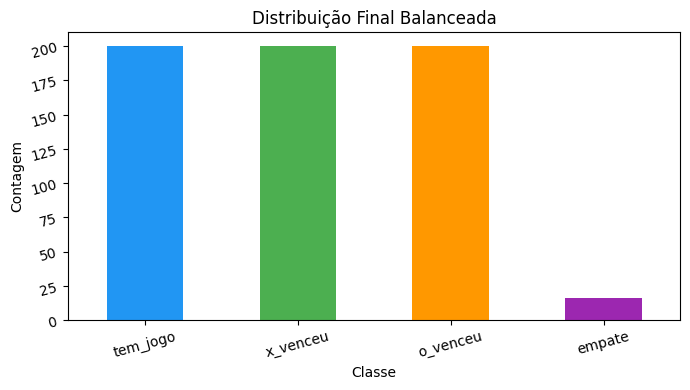

In [15]:
# 2.4 - Balanceamento do dataset final

df_full = pd.concat([df, df_synthetic], ignore_index=True)

print('### Distribuição antes do balanceamento')
print(df_full['label'].value_counts())
print()

# Undersampling: até 200 amostras por classe
# Justificativa: undersampling preserva a qualidade das amostras e evita
# a criação de exemplos artificiais que poderiam degradar o modelo.

# SAMPLES_PER_CLASS definida nas variáveis globais;

dfs_per_class = []
for class_name in CLASS_NAMES:
    df_class = df_full[df_full['label'] == class_name]
    n_sample = min(SAMPLES_PER_CLASS, len(df_class))
    df_sampled = df_class.sample(n=n_sample, random_state=RANDOM_STATE)
    dfs_per_class.append(df_sampled)
    print(f'  {class_name}: {len(df_class)} disponíveis: {n_sample} amostrados')

df_balanced = pd.concat(dfs_per_class, ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f'\nDataset balanceado: {df_balanced.shape}')
print(df_balanced['label'].value_counts())

fig_bal, ax_bal = plt.subplots(figsize=(7, 4))
df_balanced['label'].value_counts().plot(
    kind='bar', ax=ax_bal, color=['#2196F3','#4CAF50','#FF9800','#9C27B0'],
    title='Distribuição Final Balanceada'
)
ax_bal.set_xlabel('Classe')
ax_bal.set_ylabel('Contagem')
ax_bal.tick_params(rotation=15)
plt.tight_layout()
plt.show()

In [16]:
# 2.5 - Encoding numérico e salvamento

df_encoded = df_balanced.copy()

# Encoding das células: 
# x -> 1 
# o -> -1 
# b -> 0
for col in CELL_COLS:
    df_encoded[col] = df_encoded[col].map(ENCODE_MAP)

# Label encoding determinístico
le = LabelEncoder()
le.fit(CLASS_NAMES) 
y_encoded = le.transform(df_encoded['label'])
df_encoded['y'] = y_encoded

print('### Mapeamento de classes:')
for idx_cls, cls_name in enumerate(le.classes_):
    print(f'  {idx_cls} → {cls_name}')

# Salvar dataset final
df_encoded.to_csv(DATASET_FINAL_PATH, index=False)
print(f'\nDataset salvo em: {DATASET_FINAL_PATH}')
print(f'Shape: {df_encoded.shape}')
df_encoded.head()

### Mapeamento de classes:
  0 → empate
  1 → o_venceu
  2 → tem_jogo
  3 → x_venceu

Dataset salvo em: tic_tac_toe_balanced.csv
Shape: (616, 11)


,c1,c2,c3,c4,c5,c6,c7,c8,c9,label,y
0,1,0,-1,1,0,-1,0,1,0,tem_jogo,2
1,0,-1,1,1,1,1,0,-1,-1,x_venceu,3
2,-1,1,0,0,-1,0,1,1,-1,o_venceu,1
3,0,1,0,0,0,0,0,0,0,tem_jogo,2
4,1,0,-1,0,0,0,0,-1,1,tem_jogo,2


---
## Seção 3 - Pipeline ML: Splits, Scaling e Métricas

In [17]:
# 3.1 - Divisão: treino, validação e teste
# Estratégia: 70% treino, 15% validação, 15% testes
# O split fixo do dataset garante que todos os 5 algoritmos
# sejam avaliados nos mesmos conjuntos, tornando a comparação justa.
# A validação é usada para tuning de hiperparâmetros; 
# o teste é preservado apenas para avaliação final.

X = df_encoded[CELL_COLS].values
y = df_encoded['y'].values

# Primeiro split: 70% treino, 30% temporário (será divido em validação e teste em seguida)
X_treino, X_temp, y_treino, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

# Segundo split: 50% dos 30% = 15% validação, 15% teste
X_val, X_teste, y_val, y_teste = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# Treino + validação combinados (usado para refit do modelo final)
X_trainval = np.vstack([X_treino, X_val])
y_trainval = np.concatenate([y_treino, y_val])

print('### Divisão do Dataset')
print(f'Treino:           {X_treino.shape[0]:4d} amostras ({X_treino.shape[0]/len(X)*100:.0f}%)')
print(f'Validação:        {X_val.shape[0]:4d} amostras ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'Teste:            {X_teste.shape[0]:4d} amostras ({X_teste.shape[0]/len(X)*100:.0f}%)')
print(f'Treino+Val:       {X_trainval.shape[0]:4d} amostras')
print(f'Total:            {len(X):4d} amostras')

### Divisão do Dataset
Treino:            431 amostras (70%)
Validação:          92 amostras (15%)
Teste:              93 amostras (15%)
Treino+Val:        523 amostras
Total:             616 amostras


In [18]:
# 3.2 - Normalização
# O scaler é ajustado APENAS no treino para evitar data leakage.
# Tree-based models são invariantes a escala (significa que a performance do modelo não muda se multiplicar ou somar uma constante nos dados)
# k-NN, SVM e MLP são sensíveis a escala logo usamos dados escalados para todos os modelos, mantendo o pipeline consistente.

scaler = StandardScaler()
X_treino_sc = scaler.fit_transform(X_treino)
X_val_sc = scaler.transform(X_val)
X_teste_sc = scaler.transform(X_teste)
X_trainval_sc = scaler.transform(X_trainval)

print('Scaler ajustado no treino e aplicado em val/teste.')
print(f'Média (treino, primeiras 3 features): {X_treino_sc.mean(axis=0)[:3].round(4)}')
print(f'Std   (treino, primeiras 3 features): {X_treino_sc.std(axis=0)[:3].round(4)}')

Scaler ajustado no treino e aplicado em val/teste.
Média (treino, primeiras 3 features): [ 0. -0.  0.]
Std   (treino, primeiras 3 features): [1. 1. 1.]


In [19]:
# 3.3 - Funções de avaliação e busca em grid

# Avalia o modelo treinado e retorna um dicionario com suas métricas
def avaliar_modelo(nome, modelo, X_test, y_test):
    pred = modelo.predict(X_test)
    return {
        'nome': nome,
        'acuracia':        accuracy_score(y_test, pred),
        'precisao_macro':  precision_score(y_test, pred, average='macro',  zero_division=0),
        'recall_macro':    recall_score(y_test, pred, average='macro',    zero_division=0),
        'f1_macro':        f1_score(y_test, pred, average='macro',        zero_division=0),
        'precisao_por_classe': precision_score(y_test, pred, average=None, zero_division=0),
        'recall_por_classe':   recall_score(y_test, pred, average=None,   zero_division=0),
        'f1_por_classe':       f1_score(y_test, pred, average=None,       zero_division=0),
        'matriz_confusao': confusion_matrix(y_test, pred),
        'modelo': modelo
    }


# Função que encontra a melhor combinação de hiperparâmetros de um modelo testando todas combinações possíveis
#   hiperparâmetros: configurações definidas para o modelo antes do treinamento
# Para cada loop:
#  1: Cria o modelo com aqueles parâmetros via make_fn(**params)
#       make_fn: Essa notação é muito comum utilizada em funções genéricas onde o caller passa sua função a ser processada para a função.
#  2: Treina no conjunto de treino
#  3: Avalia no conjunto de validação (X_vl, y_vl) — dados que o modelo nunca viu
#  4: Guarda o F1(precisão e recall) no log e atualiza o melhor se for maior
#    Precisão: dos modelos que disse que eram classe X, quantos realmente eram
#    recall: dos que realmente eram classe X, quantos foram identificados

# Retorna: (best_params_dict, best_f1_val, df_log)

def tune_model(make_fn, param_grid, X_tr, y_tr, X_vl, y_vl):
    best_f1 = -1.0
    best_params = None
    log = []
    warnings.filterwarnings('ignore')

    for params in ParameterGrid(param_grid):
        model = make_fn(**params)
        model.fit(X_tr, y_tr)
        pred_vl = model.predict(X_vl)
        f1_vl = f1_score(y_vl, pred_vl, average='macro', zero_division=0)
        log.append({**params, 'f1_val': round(f1_vl, 4)})
        if f1_vl > best_f1:
            best_f1 = f1_vl
            best_params = params

    warnings.filterwarnings('default')
    df_log = pd.DataFrame(log).sort_values('f1_val', ascending=False)
    return best_params, best_f1, df_log

print('Funções avaliar_modelo e tune_model definidas.')

Funções avaliar_modelo e tune_model definidas.


---
## Seção 4 - Treinamento dos 5 Classificadores

Fluxo padrão para cada classificador:
1. Definição dos hiperparâmetros
2. Busca em grid no conjunto de validação (sem tocar no teste)
3. Mostrar top 10 configurações de hiperparâmetros
4. Refit do melhor modelo no conjunto treino + validação combinados
5. Modelo final pronto para avaliação no teste

In [20]:
# 4.1 - k-NN (k-Nearest Neighbors)
# Parâmetros:
#   n_neighbors: número de vizinhos
#   metric: distância euclidiana vs manhattan
#   weights: votos uniformes vs ponderados pela distância inversa

param_grid_knn = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15],
    'metric':      ['euclidean', 'manhattan'],
    'weights':     ['uniform', 'distance']
}

# Busca a melhor configuração dos hiperparâmetros para o modelo k-NN com a função declarada acima tune_model
# make_fn de tune_model aponta para: lambda **p: KNeighborsClassifier(**p)
# X_treino_sc: conjunto de treino escalado das features (do dataset)
# y_treino: labels do dataset correspondentes do treino
# X_val_sc: conjunto de validação escalado das features
# y_val: labels do dataset de validação
print('### Buscando melhores hiperparâmetros para k-NN...')
params_knn, f1_val_knn, grid_knn = tune_model(
    lambda **p: KNeighborsClassifier(**p),
    param_grid_knn,
    X_treino_sc, y_treino,
    X_val_sc, y_val
)

print(f'\n### Melhores parâmetros k-NN: {params_knn}')
print(f'### F1 macro (validação):     {f1_val_knn:.4f}')
print('\n### 10 melhores configurações:')
display(grid_knn.head(10))

# Refit no treino + validação
knn = KNeighborsClassifier(**params_knn)
knn.fit(X_trainval_sc, y_trainval)
print('\n### k-NN treinado no conjunto treino+val')

### Buscando melhores hiperparâmetros para k-NN...

### Melhores parâmetros k-NN: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
### F1 macro (validação):     0.7690

### 10 melhores configurações:


,metric,n_neighbors,weights,f1_val
23,manhattan,9,distance,0.7690
21,manhattan,7,distance,0.7518
22,manhattan,9,uniform,0.7442
18,manhattan,5,uniform,0.7365
24,manhattan,11,uniform,0.7353
20,manhattan,7,uniform,0.7175
13,euclidean,15,distance,0.6207
7,euclidean,7,distance,0.6087
27,manhattan,15,distance,0.6082
11,euclidean,11,distance,0.6033



### k-NN treinado no conjunto treino+val


In [21]:
# 4.2 - Árvore de Decisão
# Parâmetros:
#   max_depth: profundidade máxima (None = árvore completa = risco de overfitting[ajuste perto dos dados de treinamento])
#   criterion: critério de impureza (gini ou entropia)
#   min_samples_split: mínimo de amostras para split
#   min_samples_leaf: mínimo de amostras por folha (regularização)

# Gini: mede a probabilidade de classificar errado um elemento escolhido aleatoriamente
# Entropy: mede a "desordem" ou incerteza do nó
param_grid_dt = {
    'max_depth':         [None, 3, 5, 7, 10],
    'criterion':         ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4]
}

# Busca a melhor configuração dos hiperparâmetros para o modelo k-NN com a função declarada acima tune_model
# make_fn de tune_model aponta para: lambda **p: DecisionTreeClassifier(**p, random_state=RANDOM_STATE)
# X_treino_sc: conjunto de treino escalado das features (do dataset)
# y_treino: labels do dataset correspondentes do treino
# X_val_sc: conjunto de validação escalado das features
# y_val: labels do dataset de validação
print('### Buscando melhores hiperparâmetros para Árvore de Decisão...')
params_dt, f1_val_dt, grid_dt = tune_model(
    lambda **p: DecisionTreeClassifier(**p, random_state=RANDOM_STATE),
    param_grid_dt,
    X_treino_sc, y_treino,
    X_val_sc, y_val
)

print(f'\n### Melhores parâmetros Árvore de Decisão: {params_dt}')
print(f'### F1 macro (validação): {f1_val_dt:.4f}')
print('\n### 10 melhores configurações:')
display(grid_dt.head(10))

dt = DecisionTreeClassifier(**params_dt, random_state=RANDOM_STATE)
dt.fit(X_trainval_sc, y_trainval)
print('\n### Decision Tree treinado no conjunto treino+val')

### Buscando melhores hiperparâmetros para Árvore de Decisão...

### Melhores parâmetros Árvore de Decisão: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
### F1 macro (validação): 0.6682

### 10 melhores configurações:


,criterion,max_depth,min_samples_leaf,min_samples_split,f1_val
84,entropy,10.0,2,2,0.6682
48,entropy,NaN,2,2,0.6682
49,entropy,NaN,2,5,0.6605
85,entropy,10.0,2,5,0.6605
82,entropy,10.0,1,5,0.6599
46,entropy,NaN,1,5,0.6599
4,gini,NaN,2,5,0.6274
40,gini,10.0,2,5,0.6274
75,entropy,7.0,2,2,0.6218
73,entropy,7.0,1,5,0.6215



### Decision Tree treinado no conjunto treino+val


In [22]:
# 4.3 - MLP (Multilayer Perceptron)
# Parâmetros:
#   hidden_layer_sizes: topologia - 1 ou 2 camadas ocultas
#   activation: função de ativação (relu vs tanh)
#   alpha: coeficiente de regularização
#   max_iter: iterações máximas (fixo em 1000 para garantir convergência)
# Justificativa topológica: entrada = 9 features, 4 classes de saída.
# Redes com 1-2 camadas ocultas são suficientes para este problema estruturado.

# (50,): 1 camada oculta com 50 neurônios
# (100,): 1 camada oculta com 100 neurônios
# (50, 50): 2 camadas ocultas, 50 neurônios cada
# (100, 50): 2 camadas ocultas, 100 na primeira e 50 na segunda
# (64, 32): 2 camadas ocultas, 64 na primeira e 32 na segunda
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (64, 32)], # Camadas intermediarias da MLP
    'activation':         ['relu', 'tanh'],
    'alpha':              [0.0001, 0.001, 0.01],
    'max_iter':           [1000]
}

# Busca a melhor configuração dos hiperparâmetros para o modelo k-NN com a função declarada acima tune_model
# make_fn de tune_model aponta para: lambda **p: MLPClassifier(**p, random_state=RANDOM_STATE, early_stopping=False)
# X_treino_sc: conjunto de treino escalado das features (do dataset)
# y_treino: labels do dataset correspondentes do treino
# X_val_sc: conjunto de validação escalado das features
# y_val: labels do dataset de validação
print('### Buscando melhores hiperparâmetros para MLP...')
params_mlp, f1_val_mlp, grid_mlp = tune_model(
    lambda **p: MLPClassifier(**p, random_state=RANDOM_STATE, early_stopping=False),
    param_grid_mlp,
    X_treino_sc, y_treino,
    X_val_sc, y_val
)

print(f'\n### Melhores parâmetros MLP: {params_mlp}')
print(f'### F1 macro (validação): {f1_val_mlp:.4f}')
print(f'### Topologia usada: {params_mlp["hidden_layer_sizes"]}')
print('\n### 10 melhores configurações:')
display(grid_mlp.head(10))

mlp = MLPClassifier(**params_mlp, random_state=RANDOM_STATE)
mlp.fit(X_trainval_sc, y_trainval)
print('\n### MultiLayer Percepton treinado no conjunto treino+val')

### Buscando melhores hiperparâmetros para MLP...

### Melhores parâmetros MLP: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (100, 50), 'max_iter': 1000}
### F1 macro (validação): 0.6843
### Topologia usada: (100, 50)

### 10 melhores configurações:


,activation,alpha,hidden_layer_sizes,max_iter,f1_val
13,relu,0.0100,"(100, 50)",1000,0.6843
4,relu,0.0001,"(64, 32)",1000,0.6801
9,relu,0.0010,"(64, 32)",1000,0.6801
14,relu,0.0100,"(64, 32)",1000,0.6801
12,relu,0.0100,"(50, 50)",1000,0.6792
3,relu,0.0001,"(100, 50)",1000,0.6760
2,relu,0.0001,"(50, 50)",1000,0.6699
17,tanh,0.0001,"(50, 50)",1000,0.6678
22,tanh,0.0010,"(50, 50)",1000,0.6678
8,relu,0.0010,"(100, 50)",1000,0.6677



### MultiLayer Percepton treinado no conjunto treino+val


In [23]:
# 4.4 - Random Forest (Livre escolha #1)

# Como funciona: Random Forest é um conjunto de árvores de decisão treinadas
# com amostras e seleção aleatória de subconjunto de features em cada split. 
# A predição final é por votação majoritária das árvores. 
# Isso reduz variância e overfitting em relação a uma única árvore de decisão.


param_grid_rf = {
    'n_estimators': [50, 100, 200], #  número de árvores de decisão treinadas
    'max_depth':    [None, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# Busca a melhor configuração dos hiperparâmetros para o modelo k-NN com a função declarada acima tune_model
# make_fn de tune_model aponta para: lambda **p:lambda **p: RandomForestClassifier(**p, random_state=RANDOM_STATE)
# X_treino_sc: conjunto de treino escalado das features (do dataset)
# y_treino: labels do dataset correspondentes do treino
# X_val_sc: conjunto de validação escalado das features
# y_val: labels do dataset de validação
print('Buscando melhores hiperparâmetros para Random Forest...')
params_rf, f1_val_rf, grid_rf = tune_model(
    lambda **p: RandomForestClassifier(**p, random_state=RANDOM_STATE),
    param_grid_rf,
    X_treino_sc, y_treino,
    X_val_sc, y_val
)

print(f'\n### Melhores parâmetros Random Forest: {params_rf}')
print(f'### F1 macro (validação):              {f1_val_rf:.4f}')
print('\n### 10 melhores configurações:')
display(grid_rf.head(10))

rf = RandomForestClassifier(**params_rf, random_state=RANDOM_STATE)
rf.fit(X_trainval_sc, y_trainval)
print('\n### Random Forest treinado no conjunto treino+val')

Buscando melhores hiperparâmetros para Random Forest...

### Melhores parâmetros Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
### F1 macro (validação):              0.6156

### 10 melhores configurações:


,max_depth,max_features,n_estimators,f1_val
5,NaN,log2,200,0.6156
2,NaN,sqrt,200,0.6156
4,NaN,log2,100,0.5998
1,NaN,sqrt,100,0.5998
16,10.0,log2,100,0.5988
13,10.0,sqrt,100,0.5988
17,10.0,log2,200,0.5984
14,10.0,sqrt,200,0.5984
0,NaN,sqrt,50,0.5911
3,NaN,log2,50,0.5911



### Random Forest treinado no conjunto treino+val


In [24]:
# 4.5 - Naive Bayes Gaussiano (Livre escolha #2)

# Como funciona: aplica o Teorema de Bayes assumindo que as features são independentes entre si. 
# A versão Gaussiana assume que os valores de cada feature seguem uma distribuição normal. 
# Para cada classe calcula a probabilidade de um exemplo pertencer a ela e escolhe a maior.

# Justificativa da escolha: abordagem probabilística fundamentalmente diferente de todos os outros modelos
# Naive Bayes usa probabilidade condicional. É o mais simples e rápido dos 5, sem hiperparâmetros complexos.

# Parâmetros: var_smoothing: pequeno valor somado à variância para evitar probabilidade zero

param_grid_nb = {
    'var_smoothing': [0.0001, 0.001, 0.01, 0.1, 1.0]
}

print('### Buscando melhores hiperparâmetros para Naive Bayes...')
params_nb, f1_val_nb, grid_nb = tune_model(
    lambda **p: GaussianNB(**p),
    param_grid_nb,
    X_treino_sc, y_treino,
    X_val_sc, y_val
)

print(f'\n### Melhores parâmetros Naive Bayes: {params_nb}')
print(f'### F1 macro (validação):            {f1_val_nb:.4f}')
print('\n### Melhores configurações:')
display(grid_nb)

nb = GaussianNB(**params_nb)
nb.fit(X_trainval_sc, y_trainval)
print('\n### Naive Bayes treinado no conjunto treino+val')

### Buscando melhores hiperparâmetros para Naive Bayes...

### Melhores parâmetros Naive Bayes: {'var_smoothing': 0.0001}
### F1 macro (validação):            0.4276

### Melhores configurações:


,var_smoothing,f1_val
0,0.0001,0.4276
1,0.0010,0.4276
2,0.0100,0.4276
3,0.1000,0.4269
4,1.0000,0.2871



### Naive Bayes treinado no conjunto treino+val


---
## Seção 5 - Avaliação e Comparação dos Modelos

In [25]:
# 5.1 - Avaliação de todos os modelos no conjunto de TESTE

modelos_avaliados = [
    ('k-NN',           knn),
    ('Arvore Decisao', dt),
    ('MLP',            mlp),
    ('Random Forest',  rf),
    ('Naive Bayes',    nb)
]

resultados = []
for nome, modelo in modelos_avaliados:
    res = avaliar_modelo(nome, modelo, X_teste_sc, y_teste)
    resultados.append(res)
    print(f"  {nome:15s} | Acurácia: {res['acuracia']:.4f} | F1 Macro: {res['f1_macro']:.4f}")

  k-NN            | Acurácia: 0.7957 | F1 Macro: 0.6039
  Arvore Decisao  | Acurácia: 0.7419 | F1 Macro: 0.6397
  MLP             | Acurácia: 0.8710 | F1 Macro: 0.6622
  Random Forest   | Acurácia: 0.8817 | F1 Macro: 0.6708
  Naive Bayes     | Acurácia: 0.6129 | F1 Macro: 0.4696


In [26]:
# 5.2 — Tabela comparativa

df_comparacao = pd.DataFrame([{
    'Modelo':            r['nome'],
    'Acuracia':       round(r['acuracia'],       4),
    'Precisao_Macro': round(r['precisao_macro'], 4),
    'Recall_Macro':   round(r['recall_macro'],   4),
    'F1_Macro':       round(r['f1_macro'],       4)
} for r in resultados])

df_comparacao = df_comparacao.set_index('Modelo')
df_comparacao.sort_values('F1_Macro', ascending=False, inplace=True)

print('### Comparação de Modelos (ordenado por F1 Macro)')
display(df_comparacao.style
        .highlight_max(color='#57bb8a')
        .highlight_min(color='#e06666')
        .format('{:.4f}'))

### Comparação de Modelos (ordenado por F1 Macro)


,Acuracia,Precisao_Macro,Recall_Macro,F1_Macro
Modelo,,,,
Random Forest,0.8817,0.6623,0.6833,0.6708
MLP,0.8710,0.6518,0.6750,0.6622
Arvore Decisao,0.7419,0.6380,0.6500,0.6397
k-NN,0.7957,0.6059,0.6167,0.6039
Naive Bayes,0.6129,0.4791,0.4750,0.4696


In [27]:
# 5.3 - Métricas por classe (para cada modelo)

for res in resultados:
    df_per_class = pd.DataFrame({
        'Classe':      le.classes_,
        'Precisao': res['precisao_por_classe'].round(4),
        'Recall':   res['recall_por_classe'].round(4),
        'F1':       res['f1_por_classe'].round(4)
    }).set_index('Classe')
    print(f"\n### {res['nome']}")
    display(df_per_class)


### k-NN


,Precisao,Recall,F1
Classe,,,
empate,0.0000,0.0000,0.0000
o_venceu,0.7317,1.0000,0.8451
tem_jogo,0.8400,0.7000,0.7636
x_venceu,0.8519,0.7667,0.8070



### Arvore Decisao


,Precisao,Recall,F1
Classe,,,
empate,0.2500,0.3333,0.2857
o_venceu,0.8438,0.9000,0.8710
tem_jogo,0.6667,0.7333,0.6984
x_venceu,0.7917,0.6333,0.7037



### MLP


,Precisao,Recall,F1
Classe,,,
empate,0.0000,0.0000,0.0000
o_venceu,0.8824,1.0000,0.9375
tem_jogo,0.8214,0.7667,0.7931
x_venceu,0.9032,0.9333,0.9180



### Random Forest


,Precisao,Recall,F1
Classe,,,
empate,0.0000,0.0000,0.0000
o_venceu,0.8571,1.0000,0.9231
tem_jogo,0.8889,0.8000,0.8421
x_venceu,0.9032,0.9333,0.9180



### Naive Bayes


,Precisao,Recall,F1
Classe,,,
empate,0.0000,0.0000,0.0000
o_venceu,0.5500,0.7333,0.6286
tem_jogo,0.8182,0.6000,0.6923
x_venceu,0.5484,0.5667,0.5574


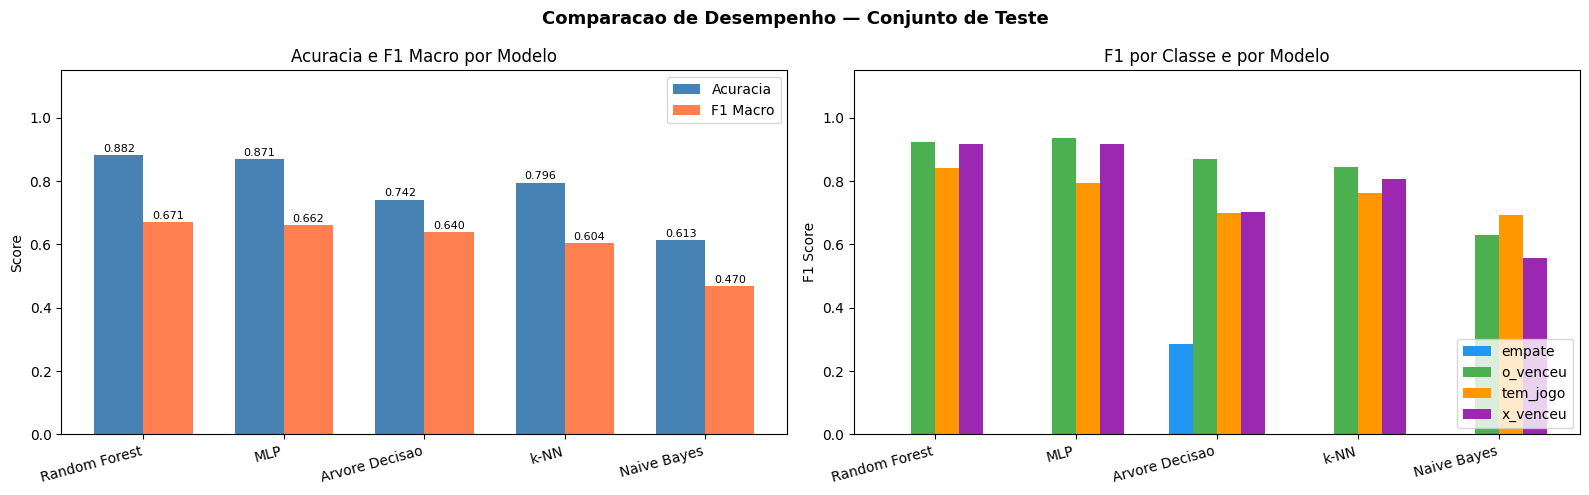

Figura salva: metrics_comparison.png


In [28]:
# 5.4 - Gráficos de comparação
# Trecho gerado com IA (apenas para geração/construção do gráfico)

nomes_modelos = df_comparacao.index.tolist()
ordered_results = [r for nm in nomes_modelos for r in resultados if r['nome'] == nm]
x_pos = np.arange(len(nomes_modelos))
width = 0.35

fig_bar, axes_bar = plt.subplots(1, 2, figsize=(16, 5))
fig_bar.suptitle('Comparacao de Desempenho — Conjunto de Teste', fontsize=13, fontweight='bold')

# Gráfico 1: Acurácia e F1 Macro
accs = [df_comparacao.loc[nm, 'Acuracia']   for nm in nomes_modelos]
f1s  = [df_comparacao.loc[nm, 'F1_Macro']   for nm in nomes_modelos]

bars1 = axes_bar[0].bar(x_pos - width/2, accs, width, label='Acuracia',  color='steelblue')
bars2 = axes_bar[0].bar(x_pos + width/2, f1s,  width, label='F1 Macro',  color='coral')
axes_bar[0].set_xticks(x_pos)
axes_bar[0].set_xticklabels(nomes_modelos, rotation=15, ha='right')
axes_bar[0].set_ylim(0, 1.15)
axes_bar[0].set_ylabel('Score')
axes_bar[0].set_title('Acuracia e F1 Macro por Modelo')
axes_bar[0].legend()
for bar in bars1:
    axes_bar[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars2:
    axes_bar[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{bar.get_height():.3f}', ha='center', fontsize=8)

# Gráfico 2: F1 por classe
colors_cls = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
bar_w = 0.17
for j, (cls, col) in enumerate(zip(le.classes_, colors_cls)):
    f1_vals = [r['f1_por_classe'][j] for r in ordered_results]
    offset = (j - 1.5) * bar_w
    axes_bar[1].bar(x_pos + offset, f1_vals, bar_w, label=cls, color=col)
axes_bar[1].set_xticks(x_pos)
axes_bar[1].set_xticklabels(nomes_modelos, rotation=15, ha='right')
axes_bar[1].set_ylim(0, 1.15)
axes_bar[1].set_ylabel('F1 Score')
axes_bar[1].set_title('F1 por Classe e por Modelo')
axes_bar[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: metrics_comparison.png')

### 5.5 - Escolha e Justificativa do Melhor Modelo

O modelo final é selecionado pelo **maior F1 Macro no conjunto de teste**. O F1 Macro é a métrica de escolha porque:
- Leva em conta precision e recall simultaneamente
    ###### precision: dos modelos que disse que eram classe X, quantos realmente eram
    ###### recall: dos que realmente eram classe X, quantos foram identificados
- É sensível ao desempenho em todas as classes (média simples, não ponderada)

Também verificamos overfitting comparando F1 no treino vs teste. Um gap > 3% é considerado indicativo de overfitting.

In [ ]:
# 5.5 - Seleção automática do melhor modelo
# Critério: dentre os modelos sem overfitting (gap <= 3%), escolhe o de maior F1.
# Se todos tiverem overfitting, escolhe o de maior F1 penalizado pelo gap (F1 - gap).

### PROBLEMA ENCONTRADO: Devido ao dataset nao conter muitos dados de empate mesmo apos o relabeling, causando:
  #1. O modelo quase não aprende a classe
  #Com 11 exemplos contra ~200 das outras classes, qualquer algoritmo tende a ignorar empate — errar empate "custa pouco" 
  # numericamente porque é raro.

  #2. F1 Macro penaliza forte
  #O F1 Macro faz a média simples entre as 4 classes. Se o modelo zera o F1 em empate (que quase todos fazem — veja a seção 5.3), 
  # ele perde 1/4 do score total, independente de acertar tudo no resto.

  #3. Overfitting artificial nos modelos complexos
  #Durante o treino, os 11 exemplos de empate são "memorizados" facilmente por modelos como Random Forest e MLP. No teste, 
  # com 2-3 amostras, qualquer erro nelas distorce o F1 de empate drasticamente (errar 1 de 3 = 33% de erro nessa classe).

  #4. Gap treino-teste inflado
  #É por isso que todos os modelos complexos têm gap de 0.26–0.39: eles decoram os 11 empates no treino (F1 alto), 
  # mas não generalizam para os 2-3 do teste (F1 zero ou próximo de zero).

def checar_overfitting(resultado):
    pred_tr = resultado['modelo'].predict(X_treino_sc)
    f1_tr = f1_score(y_treino, pred_tr, average='macro')
    gap = f1_tr - resultado['f1_macro']
    return f1_tr, gap

# Calcula gap de todos os modelos e imprime
print('### Gap treino-teste por modelo:')
candidatos = []
for nome_candidato in df_comparacao.index:
    res_candidato = next(r for r in resultados if r['nome'] == nome_candidato)
    f1_tr, gap = checar_overfitting(res_candidato)
    print(f'# {nome_candidato}: F1 teste: {res_candidato["f1_macro"]:.4f} | gap: {gap:.4f}')
    candidatos.append((nome_candidato, res_candidato, f1_tr, gap))

# Filtra modelos sem overfitting e pega o de maior F1
sem_overfitting = [(n, r, f1_tr, gap) for n, r, f1_tr, gap in candidatos if gap <= OVERFITTING_THRESHOLD]

if sem_overfitting:
    melhor_nome, melhor_resultado, f1_treino_melhor, gap_final = max(sem_overfitting, key=lambda x: x[1]['f1_macro'])
else:
    # Todos com overfitting: penaliza o F1 pelo gap e pega o melhor score
    print('\n### Todos os modelos com overfitting. Selecionando pelo maior (F1 - gap)...')
    melhor_nome, melhor_resultado, f1_treino_melhor, gap_final = max(
        candidatos, key=lambda x: x[1]['f1_macro'] - x[3]
    )

# Caso quisermos inputar na mão outro modelo:
# Nome dos modelos: 
# Random Forest: RandomForestClassifier
# MLP: MLPClassifier
# Arvore Decisao: DecisionTreeClassifier
# k-NN: KNeighborsClassifier
# Naive Bayes: GaussianNB
#melhor_resultado = [r for r in resultados if r['nome'] == 'Naive Bayes'][0]
#melhor_modelo = melhor_resultado['modelo']
melhor_modelo = melhor_resultado['modelo']

print(f'\n### Melhor Modelo Selecionado: {melhor_nome}')
print(f'# F1 Macro  (teste): {melhor_resultado["f1_macro"]:.4f}')
print(f'# Acuracia  (teste): {melhor_resultado["acuracia"]:.4f}')
print(f'# Precisao  (teste): {melhor_resultado["precisao_macro"]:.4f}')
print(f'# Recall    (teste): {melhor_resultado["recall_macro"]:.4f}')
print(f'# F1 Macro  (treino): {f1_treino_melhor:.4f}')
print(f'# Gap treino-teste: {gap_final:.4f}')
if gap_final > OVERFITTING_THRESHOLD:
    print('### Overfitting presente mesmo no modelo selecionado (gap > 3%)')
else:
    print('### Sem indícios significativos de overfitting')

### Gap treino-teste por modelo:
# Random Forest: F1 teste: 0.6708 | gap: 0.3292
# MLP: F1 teste: 0.6622 | gap: 0.3378
# Arvore Decisao: F1 teste: 0.6397 | gap: 0.2608
# k-NN: F1 teste: 0.6039 | gap: 0.3961
# Naive Bayes: F1 teste: 0.4696 | gap: 0.0119

### Melhor Modelo Selecionado: Naive Bayes
# F1 Macro  (teste): 0.4696
# Acuracia  (teste): 0.6129
# Precisao  (teste): 0.4791
# Recall    (teste): 0.4750
# F1 Macro  (treino): 0.4815
# Gap treino-teste: 0.0119
### Sem indícios significativos de overfitting


---
## Seção 6 - Verificações de Integridade

In [50]:
# Cell 7.1 - Integridade do dataset
print('### VERIFICAÇÕES DE INTEGRIDADE DO DATASET')
erros_integridade = 0

# Função auxiliar: converte o board para um array normalizado para predição
def board_to_features(board):
    encoded = np.array([ENCODE_MAP[v] for v in board], dtype=float).reshape(1, -1)
    return scaler.transform(encoded)

# Função auxiliar: converte o inteiro predito para o nome da classe
def decode_prediction(pred_int):
    return le.inverse_transform([int(pred_int)])[0]

# Valores nulos
nulos_final = df_encoded.isnull().sum().sum()
if nulos_final == 0:
    print('# Sem valores nulos')
else:
    print(f'# Nulos encontrados: {nulos_final}')
    erros_integridade += 1

# Balanceamento
contagem_cls = df_encoded['label'].value_counts()
all_balanced = all(150 <= cnt <= 200 for cnt in contagem_cls)
if all_balanced:
    print(f'# Classes balanceadas: {contagem_cls.to_dict()}')
else:
    print(f'# Classes fora do intervalo 150-200: {contagem_cls.to_dict()}')
    erros_integridade += 1

# Encoding correto
valores_invalidos = []
for col in CELL_COLS:
    invalidos = [v for v in df_encoded[col].unique() if v not in [-1, 0, 1]]
    if invalidos:
        valores_invalidos.append(f'{col}: {invalidos}')
if not valores_invalidos:
    print('# Encoding {x:1, o:-1, b:0} correto em todas as colunas')
else:
    print(f'# Valores fora de {{-1,0,1}} encontrados: {valores_invalidos}')
    erros_integridade += 1

# Duplicatas
n_dupl = df_encoded[CELL_COLS].duplicated().sum()
print(f'# {"[OK]" if n_dupl == 0 else "[NOT-OK]"} Duplicatas no dataset: {n_dupl} '
      f'(obs: tabuleiros iguais com labels diferentes são impossíveis)')

# Consistência labels vs lógica do tabuleiro
erros_label = 0
for _, row in df_balanced.iterrows():
    board_check = row_to_board(row)
    computed = classify_board(board_check)
    if computed != row['label']:
        erros_label += 1
if erros_label == 0:
    print('# Todas as labels consistentes com lógica do tabuleiro (0 erros)')
else:
    print(f'# Labels inconsistentes: {erros_label} erros!')
    erros_integridade += 1

print()
if erros_integridade == 0:
    print('### Todos os checks de integridade passaram!')
else:
    print(f'### {erros_integridade} checks falharam. Revise as seções anteriores.')

### VERIFICAÇÕES DE INTEGRIDADE DO DATASET
# Sem valores nulos
# Classes fora do intervalo 150-200: {'tem_jogo': 200, 'x_venceu': 200, 'o_venceu': 200, 'empate': 16}
# Encoding {x:1, o:-1, b:0} correto em todas as colunas
# [OK] Duplicatas no dataset: 0 (obs: tabuleiros iguais com labels diferentes são impossíveis)
# Todas as labels consistentes com lógica do tabuleiro (0 erros)

### 1 checks falharam. Revise as seções anteriores.


In [ ]:
# Cell 7.2 — Sanity checks do modelo
print('### SANITY CHECKS DO MODELO')

_sanity_cases = [
    (['b','b','b','b','b','b','b','b','b'], 'tem_jogo',  'Tabuleiro vazio'),
    (['x','x','x','o','o','b','b','b','b'], 'x_venceu',  'X vence linha superior'),
    (['o','o','o','x','x','b','b','b','b'], 'o_venceu',  'O vence linha superior'),
    (['x','o','x','x','o','o','o','x','x'], 'empate',    'Empate (tabuleiro cheio)'),
    (['x','b','b','b','o','b','b','b','b'], 'tem_jogo',  'Jogo em andamento (2 pecas)'),
]

all_sanity_passed = True
for board_sc, expected, desc in _sanity_cases:
    # Verificação lógica
    true_cls = classify_board(board_sc)
    logic_ok = (true_cls == expected)

    # Verificação do modelo
    feat_sc = board_to_features(board_sc)
    pred_sc = decode_prediction(melhor_modelo.predict(feat_sc)[0])
    model_ok = (pred_sc == expected)

    icon_logic = '[OK]' if logic_ok  else '[NOT-OK]'
    icon_model = '[OK]' if model_ok  else '[NOT-OK]'
    print(f'{icon_logic} Lógica | {icon_model} Modelo | [{desc}]')
    print(f'  Esperado: {expected:12s} | Lógica: {true_cls:12s} | Modelo: {pred_sc}')

    if not logic_ok:
        all_sanity_passed = False

print()
if all_sanity_passed:
    print('### Todos os sanity checks de lógica passaram!')
else:
    print('### Algum sanity check de lógica falhou')

### SANITY CHECKS DO MODELO
[OK] Lógica | [OK] Modelo | [Tabuleiro vazio]
  Esperado: tem_jogo     | Lógica: tem_jogo     | Modelo: tem_jogo
[OK] Lógica | [NOT-OK] Modelo | [X vence linha superior]
  Esperado: x_venceu     | Lógica: x_venceu     | Modelo: o_venceu
[OK] Lógica | [NOT-OK] Modelo | [O vence linha superior]
  Esperado: o_venceu     | Lógica: o_venceu     | Modelo: tem_jogo
[OK] Lógica | [NOT-OK] Modelo | [Empate (tabuleiro cheio)]
  Esperado: empate       | Lógica: empate       | Modelo: o_venceu
[OK] Lógica | [OK] Modelo | [Jogo em andamento (2 pecas)]
  Esperado: tem_jogo     | Lógica: tem_jogo     | Modelo: tem_jogo

✅ Todos os sanity checks de lógica passaram!


---
## Exportar Modelos para o Frontend

Execute a celula abaixo apos concluir o treinamento. Os modelos serao salvos em `frontend/models/` para uso pelo servidor Flask.

```bash
cd frontend
pip install -r requirements.txt
python app.py
```
Acesse: http://localhost:5000

In [52]:
# Cell EXPORT — Exportar modelos para o Frontend
# Execute esta celula apos treinar todos os modelos (Secao 4).
# Os arquivos serao salvos em frontend/models/ para uso pelo app Flask.

import joblib, os

FRONTEND_MODELS_DIR = os.path.join('frontend', 'models')
os.makedirs(FRONTEND_MODELS_DIR, exist_ok=True)

joblib.dump(melhor_modelo, os.path.join(FRONTEND_MODELS_DIR, 'melhor_modelo.pkl'))
joblib.dump(scaler,        os.path.join(FRONTEND_MODELS_DIR, 'scaler.pkl'))
joblib.dump(le,            os.path.join(FRONTEND_MODELS_DIR, 'le.pkl'))

with open(os.path.join(FRONTEND_MODELS_DIR, 'model_info.txt'), 'w') as f:
    f.write(melhor_nome)

print(f'Modelos exportados para: {os.path.abspath(FRONTEND_MODELS_DIR)}')
print(f'  melhor_modelo.pkl  ({melhor_nome})')
print( '  scaler.pkl')
print( '  le.pkl')
print( '  model_info.txt')
print('Para iniciar o frontend: cd frontend && python app.py')

Modelos exportados para: C:\projects\intel-artificial\t1\frontend\models
  melhor_modelo.pkl  (Naive Bayes)
  scaler.pkl
  le.pkl
  model_info.txt
Para iniciar o frontend: cd frontend && python app.py
